In [3]:
#loading libraries
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
#loaging dataset
netflix_dataset = pd.read_csv(r"C:\Users\tladi\Downloads\NetFlix.csv")
df = netflix_dataset.copy()

df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...


In [18]:
#data inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   int64         
 10  genres        7770 non-null   object        
 11  description   7770 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 789.1+ KB


In [9]:
#checking for duplicate
df.duplicated().sum()

np.int64(0)

In [19]:
#checking for null values
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

In [13]:
#showing that data is unavilable (string)
df["director"] = df["director"].fillna("N/A")
df["cast"] = df["cast"].fillna("N/A")
df["country"] = df["country"].fillna("N/A")
df.isna().sum() #for display

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           7
duration         0
genres           0
description      0
dtype: int64

In [15]:
#dropping missing vaules that may affect results 
df.dropna(subset=["date_added","rating"], inplace=True)

In [16]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

In [17]:
df["date_added"] = pd.to_datetime(df["date_added"])

C:\Users\tladi\AppData\Local\Temp\ipykernel_27624\2066754708.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_added"] = pd.to_datetime(df["date_added"])


In [21]:
# what type of content dominates Netflix: Movies or TV shows
df["type"].value_counts(normalize=True) *100 #normalise is to show in percentage (fraction)

type
Movie      69.137709
TV Show    30.862291
Name: proportion, dtype: float64

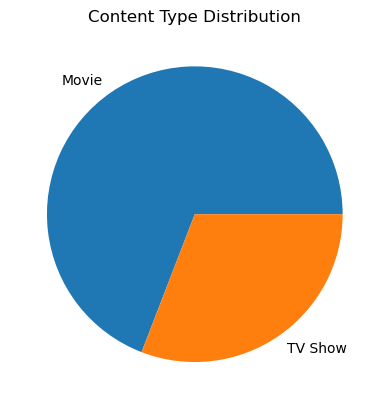

In [24]:
df["type"].value_counts(normalize=True).plot(kind='pie', ylabel="", title="Content Type Distribution")
plt.show()

<Axes: title={'center': 'Countries with top Content On Netflix'}>

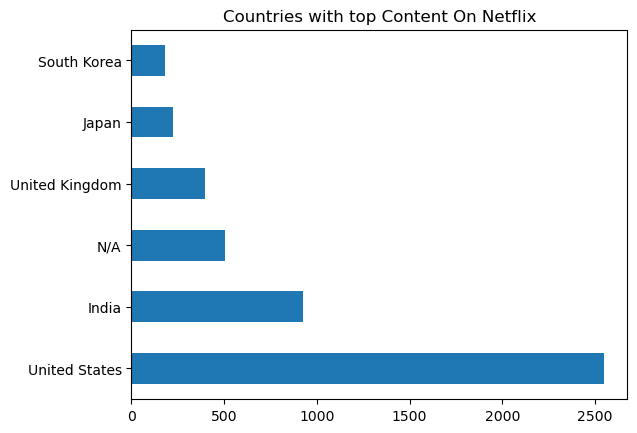

In [34]:
#what country produce the most netflix content ?
df["country"].value_counts().sort_values(ascending=False).head(6).plot(kind='barh', ylabel="", title="Countries with top Content On Netflix")

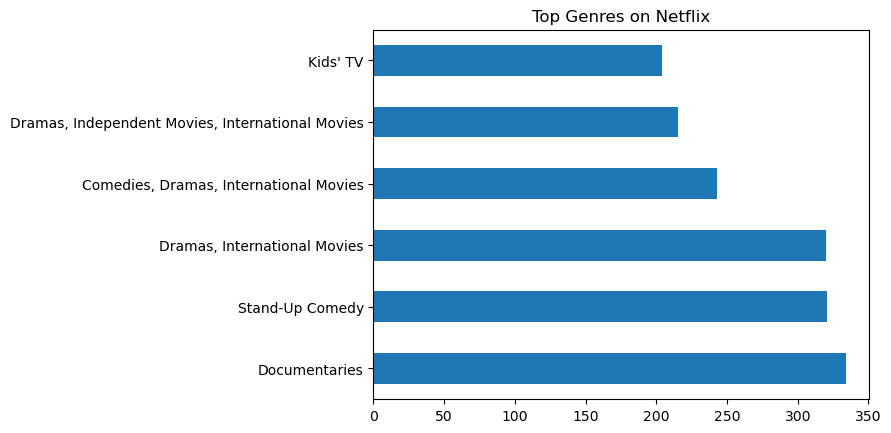

In [42]:
# what genres are most common on netflix? (what Netflix provides NOT what the viewers watch)
df["genres"].value_counts().head(6).plot(kind='barh', ylabel="", title="Top Genres on Netflix")
plt.show()

In [44]:
#how has Netflix's library grown ocer time ?
df["month"] = df["date_added"].dt.to_period("M").dt.to_timestamp()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,month
0,s1,TV Show,3%,N/A,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-01
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017-12-01
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019-01-01
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016-03-01
4,s1001,TV Show,Blue Planet II,N/A,David Attenborough,United Kingdom,2018-12-03,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018-12-01


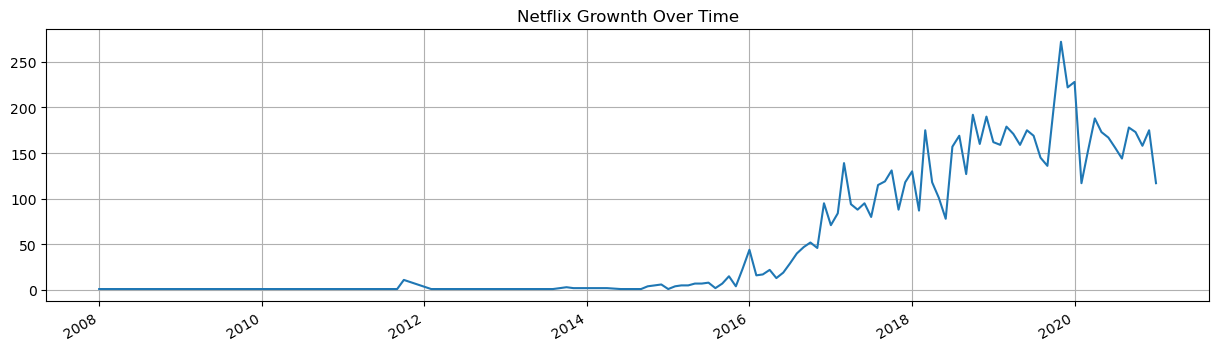

In [51]:
df.groupby("month")["type"].size().plot(kind='line', xlabel="", ylabel="", title="Netflix Grownth Over Time",grid=True, figsize=(15,4))
plt.show()

In [ ]:
#how has netflix's content  library grown over time ?

In [56]:
content_by_time = df.groupby(["month","type"]).size().reset_index(name="count")



In [59]:
content_by_time = content_by_time.pivot(index="month", columns="type", values="count")

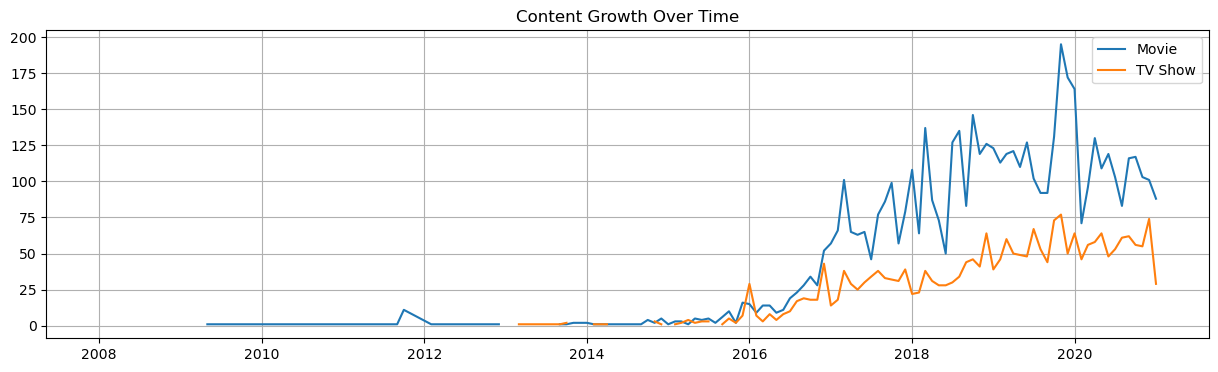

In [62]:
plt.figure(figsize=(15,4))
plt.plot(content_by_time.index, content_by_time["Movie"], label="Movie")
plt.plot(content_by_time.index, content_by_time["TV Show"], label="TV Show")
plt.legend()
plt.title("Content Growth Over Time")
plt.grid(True)

plt.show()


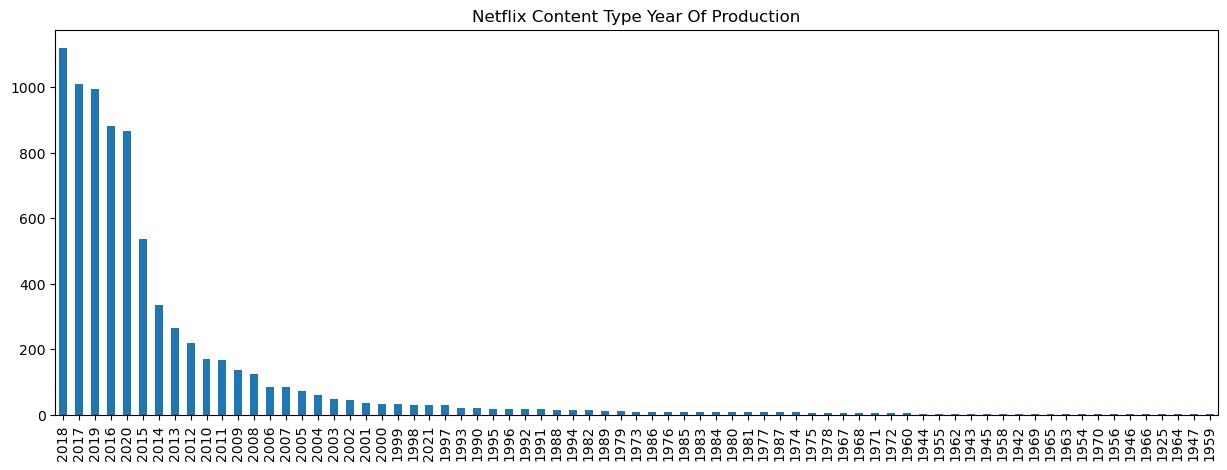

In [66]:
#what is the age distribution of Netflix content
df["release_year"].value_counts().plot(kind='bar', figsize=(15,5), xlabel="", title="Netflix Content Type Year Of Production")
plt.show()

In [67]:
#how lonh are Netflix shows and movies typically?

df_movies = df[df["type"] =="Movie"]
df_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,month
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017-12-01
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019-01-01
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016-03-01
5,s1002,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",2019-02-25,2013,R,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...,2019-02-01
6,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",2021-01-01,1999,PG-13,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...,2021-01-01


In [68]:
df_tv_show = df[df["type"] =="TV Show"]
df_tv_show.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,month
0,s1,TV Show,3%,N/A,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-01
4,s1001,TV Show,Blue Planet II,N/A,David Attenborough,United Kingdom,2018-12-03,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018-12-01
10,s1007,TV Show,BNA,N/A,"Sumire Morohoshi, Yoshimasa Hosoya, Maria Naga...",Japan,2020-06-30,2020,TV-14,1,"Anime Series, International TV Shows","Morphed into a raccoon beastman, Michiru seeks...",2020-06-01
15,s1011,TV Show,Bo on the Go!,N/A,"Catherine O'Connor, Andrew Sabiston, Jim Fowler",Canada,2019-03-21,2007,TV-Y,1,Kids' TV,Staying at home doesn't mean sitting still for...,2019-03-01
17,s1013,TV Show,Bob Ross: Beauty Is Everywhere,N/A,Bob Ross,N/A,2016-06-01,1991,TV-G,1,TV Shows,"""The Joy of Painting"" host Bob Ross brings his...",2016-06-01


In [71]:
print (f"The Median Movie Duration is {df_movies["duration"].median()}min")

The Median Duration is 98.0min


<Axes: >

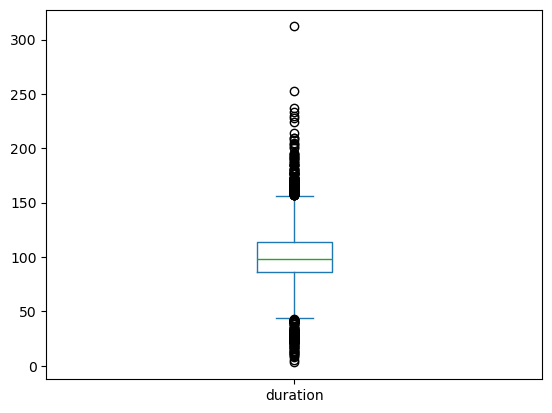

In [76]:
df_movies["duration"].plot(kind='box') # displays alot of outliers HENCE median was used for aggrigate 

In [72]:
print (f"The Median TV Show Duration is {df_tv_show["duration"].median()}hr(s)")

The Median TV Show Duration is 1.0hrs


<Axes: >

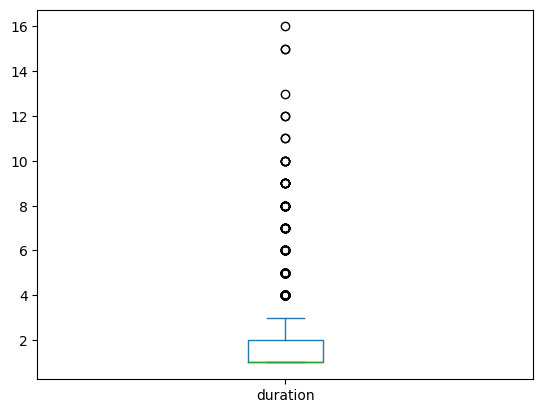

In [75]:
df_tv_show["duration"].plot(kind='box') # displays alot of outliers HENCE median was used for aggrigate 